In [ ]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.linear_model import LinearRegression

folder_path = r"D:\OneDrive\Trading\Market Making\data\runs\run_20260601_122340"

snapshots = pd.read_parquet(os.path.join(folder_path, "snapshots_new.parquet"))

snapshots

,ts,symbol,best_bid,best_ask,mid,microprice,best_bid_tick,best_ask_tick,mid_tick,spread,...,ask_delta,quote_churn,future_mid_100ms,future_return_100ms,future_mid_500ms,future_return_500ms,future_mid_1000ms,future_return_1000ms,future_mid_5000ms,future_return_5000ms
0,1780316305163,BTCUSDT,72055.76,72055.77,72055.765,72055.759989,7205576,7205577,7205576,0.01,...,0.0,0.0,72040.285,-0.000215,72028.005,-0.000385,72035.215,-0.000285,72059.955,0.000058
1,1780316305282,BTCUSDT,72039.22,72041.35,72040.285,72039.742010,7203922,7204135,7204028,2.13,...,0.0,0.0,72032.575,-0.000107,72028.005,-0.000170,72035.215,-0.000070,72059.955,0.000273
2,1780316305393,BTCUSDT,72032.57,72032.58,72032.575,72032.569895,7203257,7203258,7203258,0.01,...,0.0,0.0,72028.005,-0.000063,72028.005,-0.000063,72035.215,0.000037,72059.955,0.000380
3,1780316305483,BTCUSDT,72028.95,72029.29,72029.120,72028.952283,7202895,7202929,7202912,0.34,...,0.0,0.0,72028.005,-0.000015,72028.005,-0.000015,72035.215,0.000085,72059.955,0.000428
4,1780316305561,BTCUSDT,72028.00,72028.01,72028.005,72028.000062,7202800,7202801,7202800,0.01,...,0.0,0.0,72028.005,0.000000,72028.005,0.000000,72035.215,0.000100,72059.955,0.000444
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3150,1780316620114,BTCUSDT,72172.95,72172.96,72172.955,72172.950127,7217295,7217296,7217296,0.01,...,0.0,0.0,72172.955,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
3151,1780316620214,BTCUSDT,72172.95,72172.96,72172.955,72172.950127,7217295,7217296,7217296,0.01,...,0.0,0.0,72172.955,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
3152,1780316620314,BTCUSDT,72172.95,72172.96,72172.955,72172.950127,7217295,7217296,7217296,0.01,...,0.0,0.0,72172.955,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
3153,1780316620414,BTCUSDT,72172.95,72172.96,72172.955,72172.950129,7217295,7217296,7217296,0.01,...,0.0,0.0,72172.955,0.000000,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
"""
“Is microprice a statistically and economically meaningful estimator of future mid-price changes at horizon h?”

"""

df = snapshots

horizons = [100, 500, 1000, 5000]

df["micro_signal"] = (df["microprice"] - df["mid"]) / df["mid"]

for h in horizons:
    df[f"y_{h}ms"] = (df[f"future_mid_{h}ms"] - df["mid"]) / df["mid"]

df = df.dropna()

In [14]:
"""
(A) Pearson IC (what you are using)

captures linear relationship
sensitive to outliers
tells you “how proportional is the move?”

"""

def ic(pred, y):
    return np.corrcoef(pred, y)[0,1]

"""
(B) Rank IC (Spearman IC)

ignores magnitude
only cares about ordering
much more realistic in microstructure

In HFT, Rank IC is often more meaningful than IC.

"""

def rank_ic(pred, y):
    return spearmanr(pred, y).statistic

results = {}

for h in horizons:
    y = df[f"y_{h}ms"].values
    x = df["micro_signal"].values

    mask = np.isfinite(x) & np.isfinite(y)

    ic_val = ic(x[mask], y[mask])
    rank_ic_val = rank_ic(x[mask], y[mask])

    hit_rate = (np.sign(x[mask]) == np.sign(y[mask])).mean()

    pnl_proxy = np.mean(x[mask] * y[mask])
    pnl_std = np.std(x[mask] * y[mask])

    sharpe_proxy = pnl_proxy / (pnl_std + 1e-12)

    results[h] = {
        "Residual_IC": ic_val,
        "Residual_Rank_IC": rank_ic_val,
        "HitRate": hit_rate,
        "PnLProxy": pnl_proxy,
        "SharpeProxy": sharpe_proxy,
    }

microprice_residual_results_df = pd.DataFrame(results)
microprice_residual_results_df

,100,500,1000,5000
Residual_IC,1.560269e-01,1.239199e-01,1.041558e-01,8.477269e-02
Residual_Rank_IC,3.128291e-01,4.707285e-01,5.228688e-01,4.777103e-01
HitRate,6.441224e-02,2.164251e-01,3.375201e-01,5.977456e-01
PnLProxy,7.599800e-13,1.412672e-12,1.712677e-12,3.446768e-12
SharpeProxy,4.132219e-02,5.417044e-02,1.106400e-01,7.553320e-02


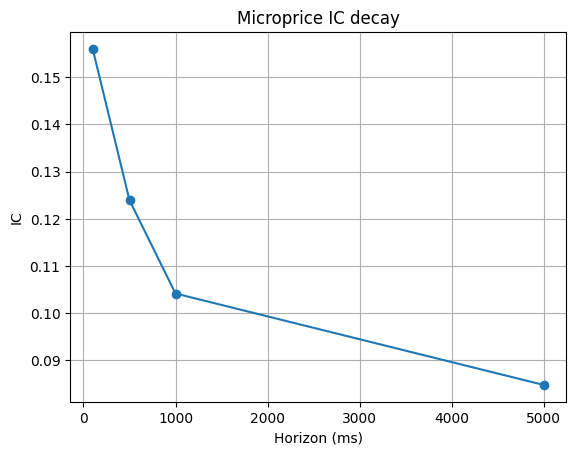

In [ ]:
ic_curve = []

for h in horizons:
    y = df[f"y_{h}ms"].values
    x = df["micro_signal"].values

    mask = np.isfinite(x) & np.isfinite(y)

    ic_curve.append(ic(x[mask], y[mask]))

plt.plot(horizons, ic_curve, marker="o")
plt.title("Microprice IC decay")
plt.xlabel("Horizon (ms)")
plt.ylabel("IC")
plt.grid()
plt.show()

In [16]:
x = df["micro_signal"].to_numpy()
y = df["future_return_100ms"].to_numpy()

reg = LinearRegression()
reg.fit(x.reshape(-1, 1), y)

print("intercept:", reg.intercept_)
print("beta:", reg.coef_[0])
print("R²:", reg.score(x.reshape(-1,1), y))

"""
So your model is approximately:

future_return_1000ms
≈
34.48 x micro_signal

You can probably ignore the intercept.

"""

intercept: 7.733044968576469e-07
beta: 14.440793192013231
R²: 0.024344403460214603


'\nSo your model is approximately:\n\nfuture_return_1000ms\n≈\n34.48 x micro_signal\n\nYou can probably ignore the intercept.\n\n'

In [ ]:
artifact = {
    "model": "micro_signal",
    "target": "(microprice - mid / mid)",
    "horizon_ms": 100,
    "intercept": 0,
    "beta": 14.44
}

joblib.dump(artifact, "micro_signal_model.pkl")